# 🤖 Agentic RAG with LangGraph
## Build a Self-Correcting, Adaptive RAG System

Traditional RAG: `Query → Retrieve → Generate` (linear, one-shot)

**Agentic RAG**: `Query → Decide → Retrieve → Grade → Rewrite? → Generate → Check` (dynamic, self-correcting)

---

### What We're Building:
1. **Query Router** - Decides: vectorstore OR web search?
2. **Document Grader** - Are retrieved docs actually relevant?
3. **Query Rewriter** - Rewrite bad queries for better retrieval
4. **Hallucination Checker** - Is the answer grounded in docs?
5. **Answer Grader** - Does the answer address the question?

---

## 1️⃣ Setup & Installation

In [1]:
!pip install -q langgraph langchain langchain-openai langchain-community \
    langchain-chroma chromadb tiktoken bs4 tavily-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 133.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/2

In [2]:
import os
from google.colab import userdata

# Set API keys (add these to Colab secrets)
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")  # For web search

print("✅ API keys configured!")

✅ API keys configured!


## 2️⃣ Load & Index Documents

In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

# Load some blog posts about AI/ML
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-tic-tac-toe/",
]

print("📄 Loading documents...")
docs = []
for url in urls:
    try:
        loader = WebBaseLoader(url)
        docs.extend(loader.load())
        print(f"   ✅ Loaded: {url.split('/')[-2]}")
    except Exception as e:
        print(f"   ⚠️ Failed: {url} - {e}")

print(f"\n📊 Total documents: {len(docs)}")

📄 Loading documents...
   ✅ Loaded: 2023-06-23-agent
   ✅ Loaded: 2023-03-15-prompt-engineering
   ✅ Loaded: 2023-10-25-adv-tic-tac-toe

📊 Total documents: 3


In [4]:
# Split documents into chunks
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,
    chunk_overlap=100,
)
doc_splits = text_splitter.split_documents(docs)
print(f"📦 Created {len(doc_splits)} chunks")

# Create vector store
print("🔄 Creating vector store...")
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings(),
    collection_name="agentic-rag"
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

print("✅ Vector store ready!")

📦 Created 55 chunks
🔄 Creating vector store...
✅ Vector store ready!


## 3️⃣ Define the Graph State

In [5]:
from typing import List, Literal
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """State of our RAG workflow."""
    question: str              # User's question
    generation: str            # LLM generated answer
    documents: List[str]       # Retrieved documents
    web_search_needed: bool    # Whether to use web search
    retry_count: int           # Number of retries

print("✅ Graph state defined!")

✅ Graph state defined!


## 4️⃣ Create the LLM & Chains

In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field

# Initialize LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print("✅ LLM initialized!")

✅ LLM initialized!


In [7]:
# ============================================================
# 1. QUERY ROUTER - Decides: vectorstore or web search?
# ============================================================

class RouteQuery(BaseModel):
    """Route query to vectorstore or web search."""
    datasource: Literal["vectorstore", "web_search"] = Field(
        description="Route to vectorstore for AI/ML/agent topics, web_search for current events or other topics"
    )

router_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert at routing questions.
Route to 'vectorstore' for questions about:
- AI agents, LLM agents, autonomous agents
- Prompt engineering, prompting techniques
- Machine learning concepts

Route to 'web_search' for:
- Current events, news
- Topics not related to AI/ML
- Questions requiring up-to-date information"""),
    ("human", "{question}")
])

query_router = router_prompt | llm.with_structured_output(RouteQuery)

# Test
print("Testing router...")
result = query_router.invoke({"question": "What are AI agents?"})
print(f"  'What are AI agents?' → {result.datasource}")
result = query_router.invoke({"question": "What's the weather today?"})
print(f"  'What's the weather?' → {result.datasource}")

Testing router...
  'What are AI agents?' → vectorstore
  'What's the weather?' → web_search


In [8]:
# ============================================================
# 2. DOCUMENT GRADER - Are retrieved docs relevant?
# ============================================================

class GradeDocuments(BaseModel):
    """Grade whether a document is relevant to the question."""
    relevant: Literal["yes", "no"] = Field(
        description="Is the document relevant to the question? 'yes' or 'no'"
    )

grader_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a grader assessing relevance of a retrieved document to a user question.
If the document contains keywords or information related to the question, grade it as relevant.
Give a binary 'yes' or 'no' score."""),
    ("human", "Document:\n{document}\n\nQuestion: {question}")
])

doc_grader = grader_prompt | llm.with_structured_output(GradeDocuments)

print("✅ Document grader ready!")

✅ Document grader ready!


In [9]:
# ============================================================
# 3. QUERY REWRITER - Improve bad queries
# ============================================================

rewriter_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a question rewriter that improves questions for better retrieval.
Look at the original question and rewrite it to be more specific and searchable.
Keep the core intent but make it clearer."""),
    ("human", "Original question: {question}\n\nImproved question:")
])

query_rewriter = rewriter_prompt | llm | StrOutputParser()

# Test
print("Testing rewriter...")
result = query_rewriter.invoke({"question": "how do agents work"})
print(f"  'how do agents work' → '{result}'")

Testing rewriter...
  'how do agents work' → 'What is the role and functionality of agents in various fields such as artificial intelligence, real estate, or customer service?'


In [10]:
# ============================================================
# 4. RAG GENERATOR - Generate answer from docs
# ============================================================

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an assistant for question-answering tasks.
Use the following retrieved context to answer the question.
If you don't know the answer, say you don't know.
Keep the answer concise - 3 sentences max."""),
    ("human", "Context:\n{context}\n\nQuestion: {question}")
])

rag_chain = rag_prompt | llm | StrOutputParser()

print("✅ RAG generator ready!")

✅ RAG generator ready!


In [11]:
# ============================================================
# 5. HALLUCINATION CHECKER - Is answer grounded in docs?
# ============================================================

class GradeHallucination(BaseModel):
    """Check if answer is grounded in the documents."""
    grounded: Literal["yes", "no"] = Field(
        description="Is the answer grounded in the provided documents? 'yes' or 'no'"
    )

hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a grader checking if an LLM answer is grounded in retrieved documents.
Check if the answer is supported by facts in the documents.
Give a binary 'yes' or 'no' score."""),
    ("human", "Documents:\n{documents}\n\nAnswer: {generation}")
])

hallucination_checker = hallucination_prompt | llm.with_structured_output(GradeHallucination)

print("✅ Hallucination checker ready!")

✅ Hallucination checker ready!


In [12]:
# ============================================================
# 6. ANSWER GRADER - Does answer address the question?
# ============================================================

class GradeAnswer(BaseModel):
    """Check if answer addresses the question."""
    addresses_question: Literal["yes", "no"] = Field(
        description="Does the answer address the question? 'yes' or 'no'"
    )

answer_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a grader checking if an answer addresses a question.
Give a binary 'yes' or 'no' score."""),
    ("human", "Question: {question}\n\nAnswer: {generation}")
])

answer_grader = answer_prompt | llm.with_structured_output(GradeAnswer)

print("✅ Answer grader ready!")

✅ Answer grader ready!


## 5️⃣ Define Graph Nodes

In [13]:
from langchain_community.tools.tavily_search import TavilySearchResults

# Web search tool
web_search_tool = TavilySearchResults(max_results=3)

# ============================================================
# NODE FUNCTIONS
# ============================================================

def retrieve(state: GraphState) -> GraphState:
    """Retrieve documents from vectorstore."""
    print("🔍 RETRIEVE: Searching vectorstore...")
    question = state["question"]
    documents = retriever.invoke(question)
    return {
        **state,
        "documents": [doc.page_content for doc in documents]
    }


def web_search(state: GraphState) -> GraphState:
    """Search the web."""
    print("🌐 WEB SEARCH: Searching the web...")
    question = state["question"]
    results = web_search_tool.invoke(question)
    documents = [r["content"] for r in results]
    return {
        **state,
        "documents": documents
    }


def grade_documents(state: GraphState) -> GraphState:
    """Grade retrieved documents for relevance."""
    print("📊 GRADE DOCS: Checking relevance...")
    question = state["question"]
    documents = state["documents"]

    relevant_docs = []
    for doc in documents:
        result = doc_grader.invoke({"document": doc, "question": question})
        if result.relevant == "yes":
            relevant_docs.append(doc)
            print(f"   ✅ Relevant doc found")
        else:
            print(f"   ❌ Irrelevant doc filtered")

    web_search_needed = len(relevant_docs) == 0
    if web_search_needed:
        print("   ⚠️ No relevant docs - will search web")

    return {
        **state,
        "documents": relevant_docs,
        "web_search_needed": web_search_needed
    }


def rewrite_query(state: GraphState) -> GraphState:
    """Rewrite the query for better retrieval."""
    print("✏️ REWRITE: Improving query...")
    question = state["question"]
    new_question = query_rewriter.invoke({"question": question})
    print(f"   '{question}' → '{new_question}'")
    return {
        **state,
        "question": new_question,
        "retry_count": state.get("retry_count", 0) + 1
    }


def generate(state: GraphState) -> GraphState:
    """Generate answer from documents."""
    print("💡 GENERATE: Creating answer...")
    question = state["question"]
    documents = state["documents"]
    context = "\n\n".join(documents)
    generation = rag_chain.invoke({"context": context, "question": question})
    return {
        **state,
        "generation": generation
    }

print("✅ All nodes defined!")

✅ All nodes defined!


/tmp/ipykernel_5716/1064587107.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(max_results=3)


## 6️⃣ Define Conditional Edges

In [14]:
# ============================================================
# CONDITIONAL EDGE FUNCTIONS
# ============================================================

def route_question(state: GraphState) -> Literal["retrieve", "web_search"]:
    """Route question to vectorstore or web search."""
    print("🚦 ROUTING: Deciding data source...")
    question = state["question"]
    result = query_router.invoke({"question": question})
    print(f"   → {result.datasource}")
    return result.datasource


def decide_to_generate(state: GraphState) -> Literal["generate", "rewrite_query", "web_search"]:
    """Decide next step after grading documents."""

    # If no relevant docs and haven't searched web yet
    if state.get("web_search_needed", False):
        # Limit retries
        if state.get("retry_count", 0) >= 2:
            print("   → web_search (max retries)")
            return "web_search"
        print("   → rewrite_query")
        return "rewrite_query"

    print("   → generate")
    return "generate"


def check_hallucination(state: GraphState) -> Literal["useful", "not_useful"]:
    """Check if answer is grounded and useful."""
    print("🔎 CHECK: Verifying answer quality...")

    documents = state["documents"]
    generation = state["generation"]
    question = state["question"]

    # Check hallucination
    docs_text = "\n\n".join(documents)
    hallucination_result = hallucination_checker.invoke({
        "documents": docs_text,
        "generation": generation
    })

    if hallucination_result.grounded == "no":
        print("   ❌ Answer not grounded - regenerating")
        return "not_useful"

    # Check if addresses question
    answer_result = answer_grader.invoke({
        "question": question,
        "generation": generation
    })

    if answer_result.addresses_question == "no":
        print("   ❌ Answer doesn't address question - regenerating")
        return "not_useful"

    print("   ✅ Answer is good!")
    return "useful"

print("✅ Conditional edges defined!")

✅ Conditional edges defined!


## 7️⃣ Build the Graph

In [19]:
from langgraph.graph import StateGraph, START, END

# Create the graph
workflow = StateGraph(GraphState)

# Add nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("web_search", web_search)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate", generate)

# Add edges
# Start → Route to retrieve or web_search
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "vectorstore": "retrieve",
        "web_search": "web_search",
    }
)

# After retrieve → grade documents
workflow.add_edge("retrieve", "grade_documents")

# After grading → decide next step
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "generate": "generate",
        "rewrite_query": "rewrite_query",
        "web_search": "web_search",
    }
)

# After rewrite → retrieve again
workflow.add_edge("rewrite_query", "retrieve")

# After web search → generate
workflow.add_edge("web_search", "generate")

# After generate → check quality → end or retry
workflow.add_conditional_edges(
    "generate",
    check_hallucination,
    {
        "useful": END,
        "not_useful": "rewrite_query",
    }
)

# Compile
app = workflow.compile()

print("✅ Graph compiled!")

✅ Graph compiled!


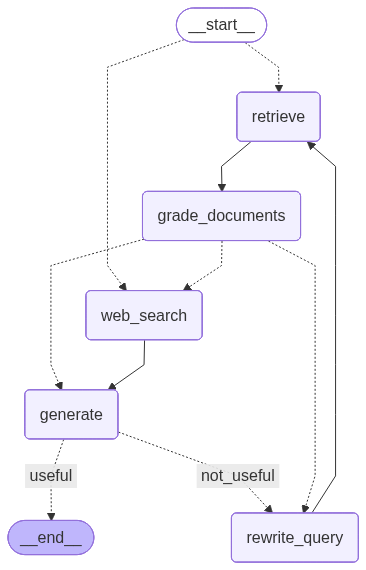

In [16]:
# Visualize the graph
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    print("Graph visualization requires additional packages")
    print("Install with: pip install grandalf")

## 8️⃣ Test the Agentic RAG!

In [20]:
def run_rag(question: str):
    """Run the agentic RAG pipeline."""
    print("="*70)
    print(f"❓ QUESTION: {question}")
    print("="*70 + "\n")

    result = app.invoke({
        "question": question,
        "generation": "",
        "documents": [],
        "web_search_needed": False,
        "retry_count": 0
    })

    print("\n" + "="*70)
    print("💡 FINAL ANSWER:")
    print("="*70)
    print(result["generation"])
    print("="*70 + "\n")

    return result

In [21]:
# Test 1: Question about AI agents (should use vectorstore)
result = run_rag("What are the main components of an AI agent?")

❓ QUESTION: What are the main components of an AI agent?

🚦 ROUTING: Deciding data source...
   → vectorstore
🔍 RETRIEVE: Searching vectorstore...
📊 GRADE DOCS: Checking relevance...
   ✅ Relevant doc found
   ✅ Relevant doc found
   ❌ Irrelevant doc filtered
   ✅ Relevant doc found
   → generate
💡 GENERATE: Creating answer...
🔎 CHECK: Verifying answer quality...
   ✅ Answer is good!

💡 FINAL ANSWER:
The main components of an AI agent include planning, memory, and tool use. Planning involves task decomposition and self-reflection to manage complex tasks effectively. Memory encompasses short-term and long-term memory for learning and retaining information, while tool use allows the agent to access external resources and APIs for additional information.



In [22]:
# Test 2: Question about prompt engineering (should use vectorstore)
result = run_rag("What are some effective prompt engineering techniques?")

❓ QUESTION: What are some effective prompt engineering techniques?

🚦 ROUTING: Deciding data source...
   → vectorstore
🔍 RETRIEVE: Searching vectorstore...
📊 GRADE DOCS: Checking relevance...
   ✅ Relevant doc found
   ✅ Relevant doc found
   ✅ Relevant doc found
   ❌ Irrelevant doc filtered
   → generate
💡 GENERATE: Creating answer...
🔎 CHECK: Verifying answer quality...
   ✅ Answer is good!

💡 FINAL ANSWER:
Some effective prompt engineering techniques include zero-shot and few-shot learning, where zero-shot involves providing the task text directly to the model, while few-shot presents high-quality demonstrations of input-output pairs to guide the model's understanding. Additionally, instruction prompting, self-consistency sampling, and chain-of-thought (CoT) prompting are also valuable methods to enhance model performance. Each technique may require experimentation to determine its effectiveness with different language models.



In [23]:
# Test 3: Current events question (should use web search)
result = run_rag("What are the latest developments in AI regulation?")

❓ QUESTION: What are the latest developments in AI regulation?

🚦 ROUTING: Deciding data source...
   → web_search
🌐 WEB SEARCH: Searching the web...
💡 GENERATE: Creating answer...
🔎 CHECK: Verifying answer quality...
   ✅ Answer is good!

💡 FINAL ANSWER:
The latest developments in AI regulation include the Biden Administration's Executive Order, which emphasizes community input and aims to address regulatory fragmentation without establishing federal standards. Additionally, there is a focus on automated employment decision tools, with new duties for employers regarding bias audits and monitoring. The recent America’s AI Action Plan indicates a shift towards deregulation, prioritizing innovation while highlighting the need for the private sector to manage AI risks in the absence of legal mandates.



In [24]:
# Test 4: Question that might need query rewriting
result = run_rag("how agents think")

❓ QUESTION: how agents think

🚦 ROUTING: Deciding data source...
   → vectorstore
🔍 RETRIEVE: Searching vectorstore...
📊 GRADE DOCS: Checking relevance...
   ✅ Relevant doc found
   ✅ Relevant doc found
   ❌ Irrelevant doc filtered
   ✅ Relevant doc found
   → generate
💡 GENERATE: Creating answer...
🔎 CHECK: Verifying answer quality...
   ✅ Answer is good!

💡 FINAL ANSWER:
Agents think by decomposing complex tasks into smaller, manageable steps, often using techniques like Chain of Thought (CoT) or Tree of Thoughts to explore multiple reasoning possibilities. They also utilize self-reflection to iteratively improve their decision-making by analyzing past actions and correcting mistakes. Additionally, some agents may rely on external planners to assist in long-horizon planning, translating problems into a structured format for better processing.



## 9️⃣ Interactive Testing

In [25]:
# @title 🤖 Ask the Agentic RAG { run: "auto" }
# @markdown Enter your question:

question = "What is chain-of-thought prompting?" # @param {type:"string"}

result = run_rag(question)

❓ QUESTION: What is chain-of-thought prompting?

🚦 ROUTING: Deciding data source...
   → vectorstore
🔍 RETRIEVE: Searching vectorstore...
📊 GRADE DOCS: Checking relevance...
   ✅ Relevant doc found
   ❌ Irrelevant doc filtered
   ✅ Relevant doc found
   ❌ Irrelevant doc filtered
   → generate
💡 GENERATE: Creating answer...
🔎 CHECK: Verifying answer quality...
   ✅ Answer is good!

💡 FINAL ANSWER:
Chain-of-thought prompting is a technique used in language models to enhance reasoning capabilities by encouraging the model to generate intermediate reasoning steps before arriving at a final answer. This method helps the model articulate its thought process, making it more effective at tackling complex, multi-step questions. It has been shown to improve performance in tasks that require deeper reasoning and understanding.



## 🔟 Understanding the Flow

```
┌─────────────┐
│   START     │
└──────┬──────┘
       │
       ▼
┌─────────────┐      AI topic?      ┌─────────────┐
│   ROUTER    │ ─────────────────► │  RETRIEVE   │
└─────────────┘                     └──────┬──────┘
       │                                   │
       │ Other?                            ▼
       │                           ┌─────────────┐
       │                           │ GRADE DOCS  │
       │                           └──────┬──────┘
       │                                  │
       ▼                    Relevant? ────┴──── Not relevant?
┌─────────────┐                │                    │
│ WEB SEARCH  │                ▼                    ▼
└──────┬──────┘         ┌───────────┐        ┌───────────┐
       │                │ GENERATE  │        │  REWRITE  │
       │                └─────┬─────┘        └─────┬─────┘
       │                      │                    │
       └──────────────────────┴────────────────────┘
                              │
                              ▼
                    ┌─────────────────┐
                    │ CHECK QUALITY   │
                    └────────┬────────┘
                             │
                    Good? ───┴─── Bad?
                      │            │
                      ▼            └──► Retry
                   ┌─────┐
                   │ END │
                   └─────┘
```

## 1️⃣1️⃣ Key Concepts

| Component | Purpose |
|-----------|--------|
| **Query Router** | Decides vectorstore vs web search |
| **Document Grader** | Filters irrelevant documents |
| **Query Rewriter** | Improves bad queries |
| **Hallucination Checker** | Ensures answer is grounded |
| **Answer Grader** | Verifies answer addresses question |

### Why LangGraph?

- **State Management**: Tracks question, docs, retries across nodes
- **Conditional Edges**: Dynamic routing based on results
- **Cycles**: Can retry/rewrite until quality is good
- **Debugging**: Clear node-by-node execution trace

---
## 🎉 What You Built

An **Agentic RAG system** that:
1. Routes queries intelligently
2. Grades document relevance
3. Rewrites bad queries
4. Falls back to web search
5. Checks for hallucinations
6. Self-corrects until the answer is good

This is NOT your grandfather's RAG! 🚀